Set Up Google Colab

In [ ]:
import os

# Create folders
base_dir = "/content/SentimentAnalysis"
os.makedirs(base_dir + "/data", exist_ok=True)
os.makedirs(base_dir + "/models", exist_ok=True)
os.makedirs(base_dir + "/results", exist_ok=True)

print("Folders created:", os.listdir(base_dir))

Folders created: ['results', 'data', 'models']


Get the Dataset from Kaggle

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/SentimentAnalysis/data/sentiment_data.csv")

# Show the first few rows
print("First 5 rows:")
print(df.head())

# Show column names
print("\nColumn names:")
print(df.columns.tolist())

# Check how many samples of each sentiment
print("\nSentiment class distribution:")
print(df['Sentiment'].value_counts())

First 5 rows:
   Unnamed: 0                                            Comment  Sentiment
0           0  lets forget apple pay required brand new iphon...          1
1           1  nz retailers don’t even contactless credit car...          0
2           2  forever acknowledge channel help lessons ideas...          2
3           3  whenever go place doesn’t take apple pay doesn...          0
4           4  apple pay convenient secure easy use used kore...          2

Column names:
['Unnamed: 0', 'Comment', 'Sentiment']

Sentiment class distribution:
Sentiment
2    103059
1     82972
0     55114
Name: count, dtype: int64


Preprocess the Text Data

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Step 1: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df['Comment'].astype(str),  # convert to string just in case
    df['Sentiment'].astype(int),
    test_size=0.2,
    random_state=42,
    stratify=df['Sentiment']  # keeps class balance
)

# Step 2: Tokenize the text
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Step 3: Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Step 4: Pad sequences to make them equal length
X_train_pad = pad_sequences(X_train_seq, maxlen=100, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=100, padding='post', truncating='post')

# Step 5: Convert labels to arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

# Check shapes
print("Training shape:", X_train_pad.shape, y_train.shape)
print("Testing shape:", X_test_pad.shape, y_test.shape)

Training shape: (192916, 100) (192916,)
Testing shape: (48229, 100) (48229,)


 Build the LSTM Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Bidirectional, LSTM

model = tf.keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=64),
    Bidirectional(LSTM(64)),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
])

# Compile the model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Show model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train the LSTM Model

In [ ]:
# Train the model
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5
3015/3015 ━━━━━━━━━━━━━━━━━━━━ 480s 158ms/step - accuracy: 0.7153 - loss: 0.6786 - val_accuracy: 0.8301 - val_loss: 0.4543
Epoch 2/5
3015/3015 ━━━━━━━━━━━━━━━━━━━━ 475s 158ms/step - accuracy: 0.8455 - loss: 0.4194 - val_accuracy: 0.8422 - val_loss: 0.4335
Epoch 3/5
3015/3015 ━━━━━━━━━━━━━━━━━━━━ 465s 154ms/step - accuracy: 0.8654 - loss: 0.3699 - val_accuracy: 0.8507 - val_loss: 0.4163
Epoch 4/5
3015/3015 ━━━━━━━━━━━━━━━━━━━━ 475s 158ms/step - accuracy: 0.8835 - loss: 0.3212 - val_accuracy: 0.8532 - val_loss: 0.4209
Epoch 5/5
3015/3015 ━━━━━━━━━━━━━━━━━━━━ 490s 154ms/step - accuracy: 0.9011 - loss: 0.2713 - val_accuracy: 0.8510 - val_loss: 0.4481


Evaluate and Visualize the Model

In [ ]:
# Evaluate model performance on test data
loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss: {loss:.4f}")

Test Accuracy: 0.8510
Test Loss: 0.4481


In [ ]:
Plot training vs validation accuracy

SyntaxError: invalid syntax (ipython-input-2630935161.py, line 1)

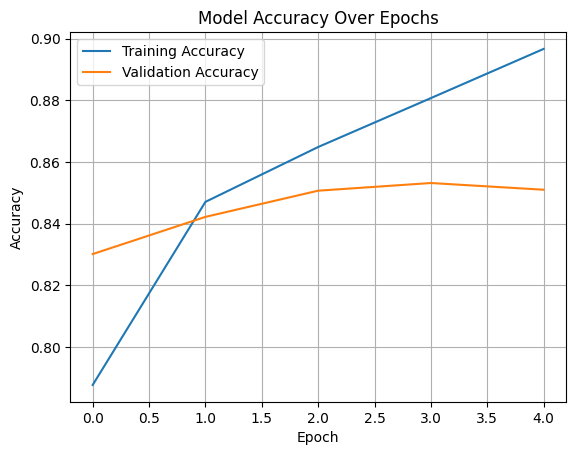

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Classification report and confusion matrix

1508/1508 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative     0.8195    0.7746    0.7964     11023
     Neutral     0.8305    0.8707    0.8501     16594
    Positive     0.8846    0.8760    0.8803     20612

    accuracy                         0.8510     48229
   macro avg     0.8448    0.8404    0.8423     48229
weighted avg     0.8511    0.8510    0.8507     48229



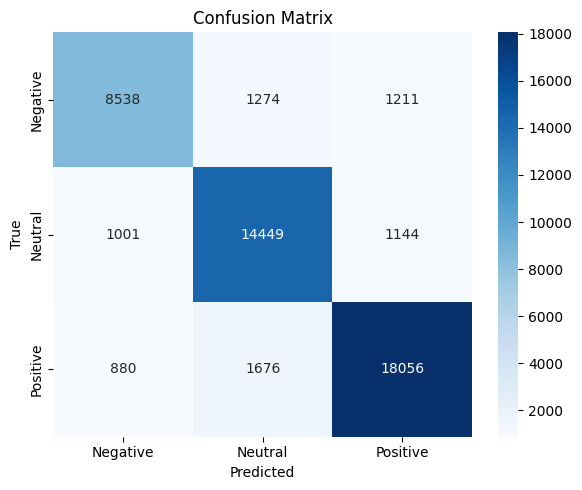

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Predict class labels
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4, target_names=["Negative", "Neutral", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

Save the Model and Tokenizer

In [ ]:
# Save the trained model
model.save("/content/SentimentAnalysis/models/sentiment_lstm.h5")

# Save the tokenizer
tokenizer_json = tokenizer.to_json()
with open("/content/SentimentAnalysis/models/tokenizer.json", "w") as f:
    f.write(tokenizer_json)

print("Model and tokenizer saved successfully.")

Model and tokenizer saved successfully.


Testing Own Sentence

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(texts):
    seq = tokenizer.texts_to_sequences([str(t) for t in texts])
    pad = pad_sequences(seq, maxlen=100, padding='post')
    probs = model.predict(pad, verbose=0)
    preds = np.argmax(probs, axis=1)
    label_map = {0:"Negative", 1:"Neutral", 2:"Positive"}
    return [(t, label_map[int(p)], float(probs[i][int(p)])) for i,(t,p) in enumerate(zip(texts, preds))]

# Try with your own examples
samples = [
    "I love using Apple Pay, it's so easy!",
    "The service was okay, not great.",
    "This app is terrible and crashes all the time."
]

for text, label, conf in predict_sentiment(samples):
    print(f"Text: {text}\nPredicted: {label} (confidence={conf:.3f})\n")

Text: I love using Apple Pay, it's so easy!
Predicted: Positive (confidence=0.775)

Text: The service was okay, not great.
Predicted: Positive (confidence=0.742)

Text: This app is terrible and crashes all the time.
Predicted: Negative (confidence=0.943)

